<a href="https://colab.research.google.com/github/adhiyaaa23/Chatbot-Supply-Chain/blob/main/nexusgen_supply_chain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ File Streamlit app disimpan: nexusgen_app.py
   Jalankan dengan: streamlit run nexusgen_app.py
  NexusGen: Gen-AI Supply Chain Oracle
  Astra UD Trucks - Tantangan #6

📦 [1/5] Membuat dataset simulasi...
✅ Dataset Intermittent Demand berhasil dibuat.
   Periode: Jan 2022 - Dec 2024
   Total record: 180


🔍 [2/5] Menganalisis 5 jenis suku cadang...

  ▸ Memproses: Filter Oli HD
  ▸ Memproses: Kampas Rem Besar
  ▸ Memproses: Pompa Injeksi Lama
  ▸ Memproses: Gasket Kepala Silinder
  ▸ Memproses: Bearing Differential



✅ Analisis selesai!

────────────────────────────────────────────────────────────
📋 HASIL ANALISIS: Filter Oli HD
────────────────────────────────────────────────────────────
  Croston Forecast (bulan depan) : 3.39 unit
  LSTM Forecast (3 bln ke depan): [2.16 3.34 0.  ] unit
  Safety Stock Optimal           : 6 unit
  Reorder Point (ROP)            : 19 unit
  Economic Order Quantity (EOQ)  : 12 unit

  Stok Aktual di Gudang: 3 unit

🤖 [3/5] Meminta rekomendasi dari Gemini Oracle...
⚠️  Gemini API error: API key tidak ditemukan

────────────────────────────────────────────────────────────
🔮 ORACLE RECOMMENDATION:
────────────────────────────────────────────────────────────

🎯 KEPUTUSAN: PESAN SEGERA
📊 ALASAN: Stok saat ini (3 unit) dibandingkan dengan Reorder Point (19 unit).
   Model Croston memprediksi permintaan 3.39 unit/bulan dengan Safety Stock optimal 6 unit
   untuk menjaga service level 95%.
⚡ TINDAKAN KONKRET: Segera buat Purchase Order sebesar 12 unit ke supplier.
⚠️  RISIK

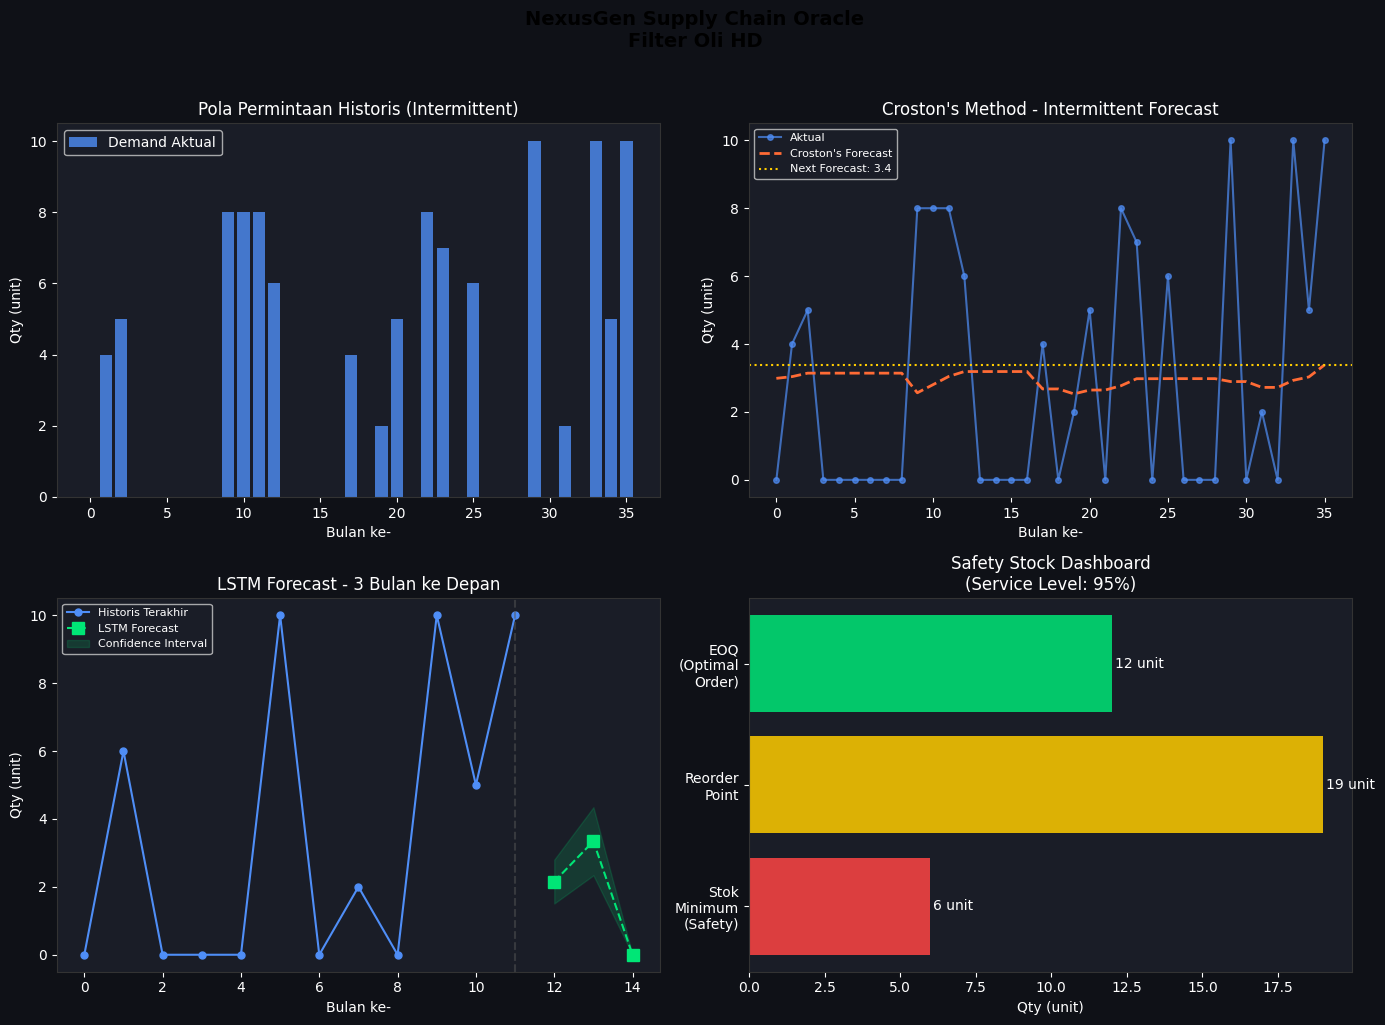

📊 Dashboard disimpan: nexusgen_dashboard.png

✅ [5/5] NexusGen Pipeline selesai!
   Untuk UI Chat Interface, jalankan: streamlit run nexusgen_app.py


In [ ]:
# =============================================================================
# NexusGen: Gen-AI Supply Chain Oracle
# Fokus: Prediksi suku cadang truk lama (Astra UD Trucks)
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

# Opsional: install terlebih dahulu via pip
# pip install google-generativeai

# ─────────────────────────────────────────────────────────────────
# MODUL 1: SIMULASI DATA HISTORIS (Pengganti Google Sheets)
# ─────────────────────────────────────────────────────────────────

def generate_intermittent_demand_data(n_months=36, seed=42):
    """
    Mensimulasikan data permintaan Intermittent (tidak rutin) selama 3 tahun.
    Pola permintaan meningkat saat musim panen/logistik tinggi (Okt-Des).
    """
    np.random.seed(seed)
    date_range = pd.date_range(start='2022-01-01', periods=n_months, freq='MS')

    spare_parts = {
        'Filter Oli HD': {'base_prob': 0.4, 'base_qty': 5},
        'Kampas Rem Besar': {'base_prob': 0.25, 'base_qty': 3},
        'Pompa Injeksi Lama': {'base_prob': 0.15, 'base_qty': 2},
        'Gasket Kepala Silinder': {'base_prob': 0.20, 'base_qty': 4},
        'Bearing Differential': {'base_prob': 0.10, 'base_qty': 1},
    }

    records = []
    for part_name, params in spare_parts.items():
        for i, date in enumerate(date_range):
            # Seasonal boost: Oktober, November, Desember (panen & logistik tinggi)
            seasonal_boost = 1.8 if date.month in [10, 11, 12] else 1.0
            # Trend kenaikan ringan seiring waktu
            trend_factor = 1 + (i / n_months) * 0.3

            prob = min(params['base_prob'] * seasonal_boost * trend_factor, 0.95)
            demand_occurs = np.random.binomial(1, prob)
            qty = 0
            if demand_occurs:
                qty = max(1, int(np.random.poisson(params['base_qty'] * seasonal_boost)))

            records.append({
                'date': date,
                'part_name': part_name,
                'demand': qty,
                'month': date.month,
                'year': date.year,
            })

    df = pd.DataFrame(records)
    print("✅ Dataset Intermittent Demand berhasil dibuat.")
    print(f"   Periode: {df['date'].min().strftime('%b %Y')} - {df['date'].max().strftime('%b %Y')}")
    print(f"   Total record: {len(df)}\n")
    return df


# ─────────────────────────────────────────────────────────────────
# MODUL 2: CROSTON'S METHOD (Forecasting Intermittent Demand)
# ─────────────────────────────────────────────────────────────────

def crostons_method(demand_series, alpha=0.1):
    """
    Metode Croston untuk data permintaan Intermittent.
    Memisahkan estimasi ukuran permintaan (a_t) dan interval antar permintaan (p_t).

    Formula: E[y_t] = a_t / p_t
    - a_t: Estimasi besarnya permintaan (exponential smoothing pada periode non-zero)
    - p_t: Estimasi interval antar permintaan

    Args:
        demand_series (list/array): Data permintaan historis
        alpha (float): Parameter smoothing (0 < alpha < 1)

    Returns:
        dict: Hasil forecast dan komponen Croston
    """
    demand = np.array(demand_series)
    n = len(demand)

    # Inisialisasi
    non_zero_demands = demand[demand > 0]
    a_t = np.mean(non_zero_demands) if len(non_zero_demands) > 0 else 1.0

    # Hitung interval awal (rata-rata jarak antar permintaan non-zero)
    non_zero_indices = np.where(demand > 0)[0]
    if len(non_zero_indices) > 1:
        p_t = np.mean(np.diff(non_zero_indices))
    else:
        p_t = n / (len(non_zero_indices) + 1)

    a_history = [a_t]
    p_history = [p_t]
    forecast_history = [a_t / p_t]

    last_non_zero = 0

    for i in range(1, n):
        if demand[i] > 0:
            # Update a_t: exponential smoothing pada demand non-zero
            a_t = alpha * demand[i] + (1 - alpha) * a_t
            # Update p_t: exponential smoothing pada interval
            interval = i - last_non_zero
            p_t = alpha * interval + (1 - alpha) * p_t
            last_non_zero = i

        # Estimasi permintaan per periode: E[y_t] = a_t / p_t
        forecast = a_t / p_t
        a_history.append(a_t)
        p_history.append(p_t)
        forecast_history.append(forecast)

    # Forecast satu langkah ke depan
    next_forecast = a_t / p_t

    return {
        'a_t': a_t,                          # Estimasi ukuran demand terakhir
        'p_t': p_t,                          # Estimasi interval terakhir
        'next_forecast': next_forecast,      # Prediksi bulan depan
        'forecast_series': forecast_history, # Riwayat prediksi
        'a_series': a_history,
        'p_series': p_history,
    }


# ─────────────────────────────────────────────────────────────────
# MODUL 3: LSTM FORECASTING (Tangkap Pola Musiman Jangka Panjang)
# ─────────────────────────────────────────────────────────────────

def lstm_forecast(demand_series, n_steps=3, n_forecast=3):
    """
    LSTM sederhana untuk menangkap pola musiman jangka panjang.
    Menggunakan TensorFlow/Keras.

    Args:
        demand_series: Data historis permintaan
        n_steps: Jumlah langkah waktu untuk input LSTM
        n_forecast: Jumlah bulan ke depan yang diprediksi

    Returns:
        array: Prediksi permintaan n_forecast bulan ke depan
    """
    try:
        import tensorflow as tf
        from tensorflow.keras.models import Sequential
        from tensorflow.keras.layers import LSTM, Dense, Dropout
        from tensorflow.keras.optimizers import Adam
    except ImportError:
        print("⚠️  TensorFlow tidak terinstal. Jalankan: pip install tensorflow")
        print("   Menggunakan simple moving average sebagai fallback...\n")
        # Fallback: Simple Moving Average
        series = np.array(demand_series, dtype=float)
        window = min(6, len(series))
        forecast = np.mean(series[-window:])
        return np.full(n_forecast, forecast)

    series = np.array(demand_series, dtype=float)

    # Normalisasi data ke range [0, 1]
    scaler = MinMaxScaler()
    series_scaled = scaler.fit_transform(series.reshape(-1, 1)).flatten()

    # Buat sequences untuk LSTM [X: n_steps nilai → y: 1 nilai berikutnya]
    X, y = [], []
    for i in range(len(series_scaled) - n_steps):
        X.append(series_scaled[i:i + n_steps])
        y.append(series_scaled[i + n_steps])

    if len(X) < 5:
        # Data terlalu sedikit untuk LSTM
        return np.full(n_forecast, np.mean(series))

    X = np.array(X).reshape(-1, n_steps, 1)
    y = np.array(y)

    # Arsitektur LSTM
    model = Sequential([
        LSTM(32, activation='tanh', input_shape=(n_steps, 1), return_sequences=True),
        Dropout(0.1),
        LSTM(16, activation='tanh'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.01), loss='mse')
    model.fit(X, y, epochs=50, batch_size=4, verbose=0)

    # Prediksi iteratif n_forecast langkah ke depan
    current_seq = series_scaled[-n_steps:].tolist()
    predictions_scaled = []

    for _ in range(n_forecast):
        input_seq = np.array(current_seq[-n_steps:]).reshape(1, n_steps, 1)
        pred = model.predict(input_seq, verbose=0)[0][0]
        predictions_scaled.append(pred)
        current_seq.append(pred)

    # Inverse transform ke skala asli
    predictions = scaler.inverse_transform(
        np.array(predictions_scaled).reshape(-1, 1)
    ).flatten()

    return np.maximum(predictions, 0)  # Tidak boleh negatif


# ─────────────────────────────────────────────────────────────────
# MODUL 4: SAFETY STOCK OPTIMIZATION
# ─────────────────────────────────────────────────────────────────

def calculate_safety_stock(demand_series, lead_time_months=2, service_level=0.95):
    """
    Menghitung Safety Stock optimal menggunakan Service Level Coefficient.

    Formula: SS = Z × σ_d × √L
    - Z: Service Level Coefficient (misal: 1.645 untuk 95%)
    - σ_d: Standar deviasi permintaan
    - L: Lead time (bulan)

    Args:
        demand_series: Data historis permintaan
        lead_time_months: Lead time pengadaan (bulan)
        service_level: Target service level (0-1), default 95%

    Returns:
        dict: Komponen safety stock dan rekomendasi stok
    """
    demand = np.array([d for d in demand_series if d > 0])  # Hanya non-zero
    if len(demand) == 0:
        demand = np.array([1])

    # Z-score dari distribusi normal untuk service level yang diinginkan
    Z = stats.norm.ppf(service_level)

    # Standar deviasi permintaan
    sigma_d = np.std(demand)
    mean_demand = np.mean(demand)

    # Rumus Safety Stock: SS = Z × σ_d × √L
    safety_stock = Z * sigma_d * np.sqrt(lead_time_months)
    safety_stock = max(1, int(np.ceil(safety_stock)))

    # Reorder Point (ROP) = Mean Demand × Lead Time + Safety Stock
    rop = mean_demand * lead_time_months + safety_stock

    # Economic Order Quantity (EOQ) sederhana
    annual_demand = mean_demand * 12
    holding_cost_per_unit = 50000   # Rp 50.000/unit/bulan (asumsi)
    order_cost = 500000             # Rp 500.000/order (asumsi)
    eoq = np.sqrt((2 * annual_demand * order_cost) / (holding_cost_per_unit * 12))

    return {
        'Z': round(Z, 4),
        'sigma_d': round(sigma_d, 4),
        'lead_time': lead_time_months,
        'service_level_pct': f"{service_level*100:.0f}%",
        'safety_stock': safety_stock,
        'mean_demand': round(mean_demand, 2),
        'reorder_point': int(np.ceil(rop)),
        'eoq': int(np.ceil(eoq)),
        'stockout_risk': f"{(1 - service_level)*100:.1f}%",
    }


# ─────────────────────────────────────────────────────────────────
# MODUL 5: GENERATIVE AI INTEGRATION (Gemini API)
# ─────────────────────────────────────────────────────────────────

def get_gemini_recommendation(part_name, croston_result, safety_stock_result,
                               lstm_forecasts, current_stock, api_key=None):
    """
    Mengintegrasikan hasil statistik dengan Gemini API untuk menghasilkan
    narasi strategis (rekomendasi tindakan).

    Args:
        part_name: Nama suku cadang
        croston_result: Output dari crostons_method()
        safety_stock_result: Output dari calculate_safety_stock()
        lstm_forecasts: Output dari lstm_forecast()
        current_stock: Stok saat ini di gudang
        api_key: Gemini API key (set via environment variable GOOGLE_API_KEY)

    Returns:
        str: Rekomendasi strategis dalam Bahasa Indonesia
    """
    # Bangun konteks statistik untuk prompt
    forecast_next = round(croston_result['next_forecast'], 2)
    safety_stock = safety_stock_result['safety_stock']
    rop = safety_stock_result['reorder_point']
    eoq = safety_stock_result['eoq']
    lstm_avg = round(float(np.mean(lstm_forecasts)), 2)

    # Tentukan urgensi berdasarkan stok vs ROP
    if current_stock <= 0:
        urgency = "KRITIS - Stok Habis"
        action = "PESAN DARURAT SEKARANG"
    elif current_stock < safety_stock:
        urgency = "TINGGI - Di Bawah Safety Stock"
        action = "PESAN SEGERA"
    elif current_stock < rop:
        urgency = "SEDANG - Mendekati Reorder Point"
        action = "RENCANAKAN PEMESANAN"
    else:
        urgency = "AMAN"
        action = "TAHAN STOK"

    # Buat prompt engineering khusus supply chain
    prompt = f"""
    Kamu adalah Oracle Supply Chain untuk perusahaan distributor suku cadang truk berat.
    Berikan rekomendasi strategis yang ringkas, jelas, dan actionable dalam Bahasa Indonesia.

    === DATA SUKU CADANG ===
    Nama Part  : {part_name}
    Stok Kini  : {current_stock} unit

    === HASIL ANALITIK ===
    Prediksi Permintaan (Croston): {forecast_next} unit/bulan
    Prediksi 3 Bulan ke Depan (LSTM): {list(np.round(lstm_forecasts, 1))} unit
    Rata-rata LSTM: {lstm_avg} unit/bulan
    Safety Stock Optimal: {safety_stock} unit
    Reorder Point (ROP): {rop} unit
    Economic Order Quantity: {eoq} unit
    Service Level Target: {safety_stock_result['service_level_pct']}
    Risiko Stockout: {safety_stock_result['stockout_risk']}

    === STATUS URGENSI ===
    Level : {urgency}
    Aksi  : {action}

    Berikan rekomendasi dalam format:
    🎯 KEPUTUSAN: [BELI SEKARANG / TAHAN STOK / WASPADA]
    📊 ALASAN: [2-3 kalimat penjelasan berbasis data di atas]
    ⚡ TINDAKAN KONKRET: [langkah spesifik yang harus diambil hari ini]
    ⚠️  RISIKO JIKA TIDAK BERTINDAK: [konsekuensi bisnis]
    """

    # Coba gunakan Gemini API
    try:
        import google.generativeai as genai
        import os

        key = api_key or os.getenv('GOOGLE_API_KEY')
        if not key:
            raise ValueError("API key tidak ditemukan")

        genai.configure(api_key=key)
        model = genai.GenerativeModel('gemini-1.5-flash')
        response = model.generate_content(prompt)
        return response.text

    except ImportError:
        print("⚠️  google-generativeai tidak terinstal. Jalankan: pip install google-generativeai")
    except Exception as e:
        print(f"⚠️  Gemini API error: {e}")

    # Fallback: Generate rekomendasi berbasis rule tanpa AI
    return f"""
🎯 KEPUTUSAN: {action}
📊 ALASAN: Stok saat ini ({current_stock} unit) dibandingkan dengan Reorder Point ({rop} unit).
   Model Croston memprediksi permintaan {forecast_next} unit/bulan dengan Safety Stock optimal {safety_stock} unit
   untuk menjaga service level {safety_stock_result['service_level_pct']}.
⚡ TINDAKAN KONKRET: {"Segera buat Purchase Order sebesar " + str(eoq) + " unit ke supplier." if action != "TAHAN STOK" else "Monitor stok mingguan. Siapkan PO jika stok turun ke " + str(rop) + " unit."}
⚠️  RISIKO JIKA TIDAK BERTINDAK: {"Downtime armada pelanggan dan kehilangan pendapatan jasa." if action != "TAHAN STOK" else "Risiko rendah saat ini, tetap pantau tren permintaan musiman."}
    """


# ─────────────────────────────────────────────────────────────────
# MODUL 6: VISUALISASI
# ─────────────────────────────────────────────────────────────────

def visualize_nexusgen(df, part_name, croston_result, safety_stock_result, lstm_forecasts):
    """Membuat dashboard visualisasi NexusGen untuk satu suku cadang."""
    part_df = df[df['part_name'] == part_name].copy()
    demand = part_df['demand'].values
    dates = part_df['date'].values

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'NexusGen Supply Chain Oracle\n{part_name}',
                 fontsize=14, fontweight='bold', y=1.02)
    fig.patch.set_facecolor('#0f1117')
    for ax in axes.flatten():
        ax.set_facecolor('#1a1d27')
        ax.tick_params(colors='white')
        ax.xaxis.label.set_color('white')
        ax.yaxis.label.set_color('white')
        ax.title.set_color('white')
        for spine in ax.spines.values():
            spine.set_edgecolor('#333')

    # Plot 1: Data Historis & Pola Intermittent
    ax1 = axes[0, 0]
    ax1.bar(range(len(demand)), demand, color='#4f8ef7', alpha=0.8, label='Demand Aktual')
    ax1.set_title('Pola Permintaan Historis (Intermittent)')
    ax1.set_xlabel('Bulan ke-')
    ax1.set_ylabel('Qty (unit)')
    ax1.legend(facecolor='#1a1d27', labelcolor='white')

    # Plot 2: Croston Forecast vs Aktual
    ax2 = axes[0, 1]
    forecast_series = croston_result['forecast_series']
    ax2.plot(range(len(demand)), demand, 'o-', color='#4f8ef7',
             alpha=0.7, label='Aktual', markersize=4)
    ax2.plot(range(len(forecast_series)), forecast_series, '--',
             color='#ff6b35', label="Croston's Forecast", linewidth=2)
    ax2.axhline(y=croston_result['next_forecast'], color='#ffcc00',
                linestyle=':', label=f"Next Forecast: {croston_result['next_forecast']:.1f}")
    ax2.set_title("Croston's Method - Intermittent Forecast")
    ax2.set_xlabel('Bulan ke-')
    ax2.set_ylabel('Qty (unit)')
    ax2.legend(facecolor='#1a1d27', labelcolor='white', fontsize=8)

    # Plot 3: LSTM Forecast 3 Bulan ke Depan
    ax3 = axes[1, 0]
    last_n = min(12, len(demand))
    ax3.plot(range(last_n), demand[-last_n:], 'o-', color='#4f8ef7',
             label='Historis Terakhir', markersize=5)
    future_x = range(last_n, last_n + len(lstm_forecasts))
    ax3.plot(future_x, lstm_forecasts, 's--', color='#00e676',
             label='LSTM Forecast', markersize=8)
    ax3.axvline(x=last_n - 1, color='#555', linestyle='--', alpha=0.5)
    ax3.fill_between(future_x,
                     np.maximum(0, lstm_forecasts * 0.7),
                     lstm_forecasts * 1.3,
                     color='#00e676', alpha=0.15, label='Confidence Interval')
    ax3.set_title('LSTM Forecast - 3 Bulan ke Depan')
    ax3.set_xlabel('Bulan ke-')
    ax3.set_ylabel('Qty (unit)')
    ax3.legend(facecolor='#1a1d27', labelcolor='white', fontsize=8)

    # Plot 4: Safety Stock Dashboard
    ax4 = axes[1, 1]
    ss = safety_stock_result
    categories = ['Stok\nMinimum\n(Safety)', 'Reorder\nPoint', 'EOQ\n(Optimal\nOrder)']
    values = [ss['safety_stock'], ss['reorder_point'], ss['eoq']]
    colors = ['#ff4444', '#ffcc00', '#00e676']
    bars = ax4.barh(categories, values, color=colors, alpha=0.85)
    for bar, val in zip(bars, values):
        ax4.text(val + 0.1, bar.get_y() + bar.get_height()/2,
                 f'{val} unit', va='center', color='white', fontsize=10)
    ax4.set_title(f'Safety Stock Dashboard\n(Service Level: {ss["service_level_pct"]})')
    ax4.set_xlabel('Qty (unit)')

    plt.tight_layout()
    plt.savefig('nexusgen_dashboard.png', dpi=150, bbox_inches='tight',
                facecolor='#0f1117')
    plt.show()
    print("📊 Dashboard disimpan: nexusgen_dashboard.png")


# ─────────────────────────────────────────────────────────────────
# MODUL 7: PIPELINE UTAMA
# ─────────────────────────────────────────────────────────────────

def run_nexusgen_pipeline(gemini_api_key=None):
    """
    Pipeline lengkap NexusGen:
    1. Load/generate data
    2. Croston's Method forecasting
    3. LSTM seasonal forecasting
    4. Safety stock optimization
    5. Gemini AI recommendation
    6. Visualisasi
    """
    print("=" * 60)
    print("  NexusGen: Gen-AI Supply Chain Oracle")
    print("  Astra UD Trucks - Tantangan #6")
    print("=" * 60)

    # 1. Generate data simulasi
    print("\n📦 [1/5] Membuat dataset simulasi...")
    df = generate_intermittent_demand_data(n_months=36)

    # 2. Pilih suku cadang untuk dianalisis (bisa diiterasi semua)
    parts = df['part_name'].unique()
    results = {}

    print(f"\n🔍 [2/5] Menganalisis {len(parts)} jenis suku cadang...\n")

    for part in parts:
        print(f"  ▸ Memproses: {part}")
        part_demand = df[df['part_name'] == part]['demand'].values

        # 3. Croston's Method
        croston = crostons_method(part_demand, alpha=0.1)

        # 4. LSTM Forecast
        lstm_pred = lstm_forecast(part_demand, n_steps=3, n_forecast=3)

        # 5. Safety Stock
        ss = calculate_safety_stock(part_demand, lead_time_months=2, service_level=0.95)

        results[part] = {
            'croston': croston,
            'lstm': lstm_pred,
            'safety_stock': ss,
        }

    print("\n✅ Analisis selesai!")

    # 6. Tampilkan hasil untuk suku cadang pertama (sebagai contoh)
    selected_part = parts[0]
    r = results[selected_part]

    print(f"\n{'─'*60}")
    print(f"📋 HASIL ANALISIS: {selected_part}")
    print(f"{'─'*60}")
    print(f"  Croston Forecast (bulan depan) : {r['croston']['next_forecast']:.2f} unit")
    print(f"  LSTM Forecast (3 bln ke depan): {np.round(r['lstm'], 2)} unit")
    print(f"  Safety Stock Optimal           : {r['safety_stock']['safety_stock']} unit")
    print(f"  Reorder Point (ROP)            : {r['safety_stock']['reorder_point']} unit")
    print(f"  Economic Order Quantity (EOQ)  : {r['safety_stock']['eoq']} unit")

    # 7. Simulasi stok saat ini (input dari sistem ERP)
    current_stock = 3  # unit (simulasi stok rendah)
    print(f"\n  Stok Aktual di Gudang: {current_stock} unit")

    # 8. Gemini AI Recommendation
    print(f"\n🤖 [3/5] Meminta rekomendasi dari Gemini Oracle...")
    recommendation = get_gemini_recommendation(
        part_name=selected_part,
        croston_result=r['croston'],
        safety_stock_result=r['safety_stock'],
        lstm_forecasts=r['lstm'],
        current_stock=current_stock,
        api_key=gemini_api_key
    )

    print(f"\n{'─'*60}")
    print("🔮 ORACLE RECOMMENDATION:")
    print(f"{'─'*60}")
    print(recommendation)

    # 9. Summary tabel semua suku cadang
    print(f"\n{'─'*60}")
    print("📊 RINGKASAN SEMUA SUKU CADANG:")
    print(f"{'─'*60}")
    summary_data = []
    for part, r in results.items():
        summary_data.append({
            'Suku Cadang': part,
            'Forecast/Bln': round(r['croston']['next_forecast'], 1),
            'Safety Stock': r['safety_stock']['safety_stock'],
            'ROP': r['safety_stock']['reorder_point'],
            'EOQ': r['safety_stock']['eoq'],
        })
    summary_df = pd.DataFrame(summary_data)
    print(summary_df.to_string(index=False))

    # 10. Visualisasi
    print(f"\n📈 [4/5] Membuat visualisasi dashboard...")
    visualize_nexusgen(df, selected_part, results[selected_part]['croston'],
                       results[selected_part]['safety_stock'], results[selected_part]['lstm'])

    print("\n✅ [5/5] NexusGen Pipeline selesai!")
    print("   Untuk UI Chat Interface, jalankan: streamlit run nexusgen_app.py")

    return df, results


# ─────────────────────────────────────────────────────────────────
# MODUL 8: STREAMLIT APP (simpan sebagai nexusgen_app.py)
# ─────────────────────────────────────────────────────────────────

STREAMLIT_CODE = '''
# nexusgen_app.py - Jalankan dengan: streamlit run nexusgen_app.py
import streamlit as st
import numpy as np
import os
# Import semua fungsi dari file utama
from nexusgen_supply_chain import (
    generate_intermittent_demand_data,
    crostons_method,
    lstm_forecast,
    calculate_safety_stock,
    get_gemini_recommendation
)

st.set_page_config(page_title="NexusGen Oracle", page_icon="⚡", layout="wide")
st.title("⚡ NexusGen: Gen-AI Supply Chain Oracle")
st.caption("Astra UD Trucks - Intelligent Spare Parts Management")

# Sidebar: Konfigurasi
with st.sidebar:
    st.header("⚙️ Konfigurasi")
    api_key = st.text_input("Gemini API Key", type="password",
                             value=os.getenv("GOOGLE_API_KEY", ""))
    service_level = st.slider("Target Service Level (%)", 90, 99, 95) / 100
    lead_time = st.slider("Lead Time (bulan)", 1, 6, 2)
    n_months = st.slider("Periode Historis (bulan)", 12, 48, 36)

# Load & cache data
@st.cache_data
def load_data(n):
    return generate_intermittent_demand_data(n_months=n)

df = load_data(n_months)
parts = df["part_name"].unique()

# Main area
col1, col2 = st.columns([2, 3])

with col1:
    st.subheader("🔍 Pilih Suku Cadang")
    selected_part = st.selectbox("Suku Cadang:", parts)
    current_stock = st.number_input("Stok Aktual (unit):", min_value=0, value=3)

    if st.button("🚀 Analisa & Minta Rekomendasi", use_container_width=True):
        with st.spinner("Menghitung model statistik..."):
            demand = df[df["part_name"] == selected_part]["demand"].values
            croston = crostons_method(demand, alpha=0.1)
            lstm_pred = lstm_forecast(demand, n_forecast=3)
            ss = calculate_safety_stock(demand, lead_time, service_level)

        # Metrics
        st.metric("Forecast Bulan Depan", f"{croston['next_forecast']:.1f} unit")
        st.metric("Safety Stock Optimal", f"{ss['safety_stock']} unit")
        st.metric("Reorder Point", f"{ss['reorder_point']} unit")

        with st.spinner("🤖 Meminta wisdom dari Oracle..."):
            rec = get_gemini_recommendation(
                selected_part, croston, ss, lstm_pred, current_stock, api_key or None
            )

        st.subheader("🔮 Oracle Recommendation")
        st.markdown(rec)

with col2:
    st.subheader("📊 Data Permintaan Historis")
    part_df = df[df["part_name"] == selected_part]
    st.bar_chart(part_df.set_index("date")["demand"])

# Chat Interface
st.divider()
st.subheader("💬 Tanya Oracle")
if "messages" not in st.session_state:
    st.session_state.messages = []

for msg in st.session_state.messages:
    with st.chat_message(msg["role"]):
        st.write(msg["content"])

if prompt := st.chat_input("Tanya tentang supply chain (e.g., 'Berapa stok aman untuk musim panen?')"):
    st.session_state.messages.append({"role": "user", "content": prompt})
    with st.chat_message("user"):
        st.write(prompt)

    # Kirim ke Gemini dengan konteks
    context = f"Kamu adalah Oracle Supply Chain Astra UD Trucks. Jawab pertanyaan ini: {prompt}"
    try:
        import google.generativeai as genai
        genai.configure(api_key=api_key)
        model = genai.GenerativeModel("gemini-1.5-flash")
        response = model.generate_content(context).text
    except:
        response = "⚠️ Harap masukkan Gemini API Key di sidebar untuk mengaktifkan Oracle AI."

    st.session_state.messages.append({"role": "assistant", "content": response})
    with st.chat_message("assistant"):
        st.write(response)
'''

def save_streamlit_app():
    """Simpan Streamlit app ke file terpisah."""
    with open('nexusgen_app.py', 'w', encoding='utf-8') as f:
        f.write(STREAMLIT_CODE.strip())
    print("✅ File Streamlit app disimpan: nexusgen_app.py")
    print("   Jalankan dengan: streamlit run nexusgen_app.py")


# ─────────────────────────────────────────────────────────────────
# ENTRY POINT
# ─────────────────────────────────────────────────────────────────

if __name__ == "__main__":
    import os

    # Set API key via environment variable atau langsung (tidak disarankan untuk produksi)
    # os.environ["GOOGLE_API_KEY"] = "your-api-key-here"

    # Simpan Streamlit app
    save_streamlit_app()

    # Jalankan pipeline utama
    df, results = run_nexusgen_pipeline(
        gemini_api_key=os.getenv("GOOGLE_API_KEY")
    )